# OpenDecider on a free Colab GPU

Open, calibrated System 1 decision models: ask typed questions (`choice`, `score`, `noul` = yes/no) about any text or
JSON and get a calibrated probability for every option. Nothing is generated, so there is nothing to parse.

* **opendecider-nano** (~400M): 16 ms per question on an NVIDIA L40S, also fast on CPU. typed-decisions 0.796, against
  0.766 for Laya's typed-decisions checkpoint (both fine-tuned on its train split).
* **opendecider-small** (4B): for decisions unlike its training data (0.735 on 200 general decisions; TypeSafe Jev
  0.730), and the best-calibrated model that fits a T4.
* **opendecider-small-td** (4B): small, fine-tuned for business workflows (typed-decisions 0.792).
* The 30B **medium-td** and 80B **large-td** need several GPUs: see the
  [collection](https://huggingface.co/collections/manjunathshiva/opendecider-6ab8c838909092518d50a9ea).

[GitHub](https://github.com/manjunathshiva/opendecider) · [Examples](https://github.com/manjunathshiva/opendecider/tree/main/examples) · [Live demo](https://huggingface.co/spaces/manjunathshiva/opendecider-demo)

**Runtime → Change runtime type → T4 GPU**, then run the cells top to bottom (about 15 minutes, most of it downloading the 8 GB base model
for section 7). The outputs below
are from a run on an NVIDIA T4.

In [1]:
!pip install -q "opendecider[small,serve]>=0.2.1" pandas pyarrow matplotlib
# Colab preinstalls torchao 0.10, which recent peft refuses to load LoRA adapters next to; OpenDecider does not use it
!pip uninstall -y -q torchao
import torch
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no GPU: Runtime > Change runtime type > T4 GPU")

Tesla T4


## 1. opendecider-nano: three typed questions about a support ticket

In [2]:
from opendecider import load, Choice, Score, Noul

nano = load("manjunathshiva/opendecider-nano")

state = "Hi, we were billed twice for March. Please refund the duplicate today or we will cancel our plan."
questions = {
    "department": Choice("Which department should handle this?",
                         {"billing": "invoices, payments, refunds", "technical": "bugs, outages, system errors",
                          "other": "everything else"}),
    "urgency": Score("How urgent is this?", ["not urgent", "soon", "blocking"]),
    "churn_risk": Noul("Does the user threaten to cancel or leave?"),
}
r = nano.system_one(state, questions)
for name, a in r["answers"].items():
    print(f"{name:11s} {a['type']:6s}", a.get("choice", a.get("score", a.get("noul"))), a["probabilities"])
print(r["latency_ms"], "ms for", len(questions), "questions")

department  choice billing {'billing': 0.9268105626106262, 'technical': 0.032951291650533676, 'other': 0.0402381494641304}
urgency     score  2 {'0': 0.09109793603420258, '1': 0.305362343788147, '2': 0.6035397052764893}
churn_risk  noul   0.9221987724304199 {'true': 0.9221987724304199, 'false': 0.07780122756958008}
75.9 ms for 3 questions


## 2. Any JSON state: an AI agent's trace

The state can be any JSON. Here the model checks an agent that keeps retrying a failing step; a guardrail would stop
it when `looping` is likely.

In [3]:
trace = {"task": "Book a table for 2 at an Italian restaurant tomorrow 7pm",
         "steps": [{"tool": "search_restaurants", "result": "3 results"},
                   {"tool": "book_table", "args": {"restaurant": "Trattoria Roma", "time": "19:00"}, "result": "error: card declined"},
                   {"tool": "book_table", "args": {"restaurant": "Trattoria Roma", "time": "19:00"}, "result": "error: card declined"}]}
r = nano.system_one(trace, {
    "next_action": Choice("What should the orchestrator do next?",
                          {"continue": "let the agent keep going", "retry": "retry the last step",
                           "ask_user": "stop and ask the user for help", "abort": "stop the task"}),
    "looping": Noul("Is the agent stuck repeating a failing step?"),
})
for name, a in r["answers"].items():
    print(name, a["probabilities"])

next_action {'continue': 0.12001897394657135, 'retry': 0.3702595829963684, 'ask_user': 0.3353826701641083, 'abort': 0.17433874309062958}
looping {'true': 0.6818220019340515, 'false': 0.3181779980659485}


## 3. Many states in one call

`system_one_batch` asks the same questions about a list of states in one padded batch, much faster than one call per
state.

In [4]:
tickets = ["The dashboard shows a 500 error since this morning and my whole team is blocked.",
           "How do I add a second admin to our workspace? No rush.",
           "Third outage this month. Send me the cancellation form.",
           "Do you offer a discount on the annual plan for nonprofits?"]
for t, r in zip(tickets, nano.system_one_batch(tickets, questions)):
    a = r["answers"]
    print(f"{t[:55]:<55} {a['department']['choice']:<9} urgency {a['urgency']['score']}  "
          f"churn p = {a['churn_risk']['noul']:.2f}")

The dashboard shows a 500 error since this morning and  technical urgency 2  churn p = 0.36
How do I add a second admin to our workspace? No rush.  other     urgency 0  churn p = 0.09
Third outage this month. Send me the cancellation form. technical urgency 2  churn p = 0.42
Do you offer a discount on the annual plan for nonprofi billing   urgency 0  churn p = 0.08


## 4. Automate only the confident decisions

Every answer has a probability, so you can act on the confident ones and send the rest to a person. This runs nano on
the whole typed-decisions test split (400 business cases, 2,000 decisions with gold labels; no OpenDecider model was
trained on it) and shows the trade-off. The same code is in
[examples/confident_automation.py](https://github.com/manjunathshiva/opendecider/blob/main/examples/confident_automation.py).

In [5]:
import json
import pandas as pd
from huggingface_hub import hf_hub_download

cases = pd.read_parquet(hf_hub_download("LocalLLaMA/typed-decisions", "all/test-00000-of-00001.parquet",
                                        repo_type="dataset"))
js = lambda v: json.loads(v) if isinstance(v, str) else v
decisions = []   # (confidence, correct)
for c in cases.itertuples():
    gold = js(c.gold)
    for q, a in nano.system_one(js(c.state), js(c.questions))["answers"].items():
        pred = ("true" if a["noul"] >= 0.5 else "false") if a["type"] == "noul" else str(a[a["type"]])
        decisions.append((a["confidence"], pred == str(gold[q]["label"])))
n = len(decisions)
print(f"{n} decisions, accuracy {sum(ok for _, ok in decisions) / n:.3f}\n")
print("automate when p >= | automated | accuracy of automated")
for t in (0.5, 0.6, 0.7, 0.8, 0.9):
    auto = [ok for p, ok in decisions if p >= t]
    print(f"{t:>17.1f} | {len(auto) / n:>8.0%} | {sum(auto) / len(auto):>21.3f}")

2000 decisions, accuracy 0.796

automate when p >= | automated | accuracy of automated
              0.5 |      76% |                 0.873
              0.6 |      51% |                 0.941
              0.7 |      32% |                 0.972
              0.8 |      21% |                 0.998
              0.9 |      13% |                 0.996


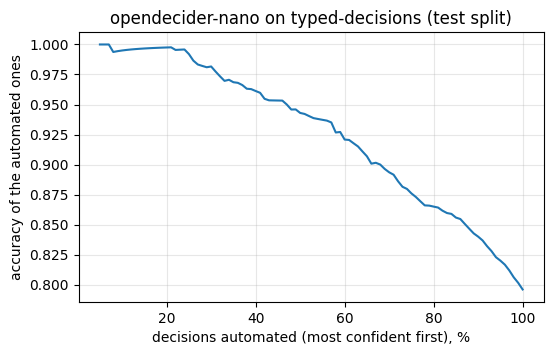

In [6]:
import matplotlib.pyplot as plt

ranked = sorted(decisions, key=lambda d: -d[0])
shares = [k / 100 for k in range(5, 101)]
acc = [sum(ok for _, ok in ranked[:round(s * n)]) / round(s * n) for s in shares]
plt.figure(figsize=(6, 3.5))
plt.plot([s * 100 for s in shares], acc)
plt.xlabel("decisions automated (most confident first), %")
plt.ylabel("accuracy of the automated ones")
plt.title("opendecider-nano on typed-decisions (test split)")
plt.grid(alpha=0.3)
plt.show()

## 5. Speed on this GPU: 1, 5, 10 and 50 questions per call

In [7]:
!python -m opendecider.bench_speed manjunathshiva/opendecider-nano

{"model": "manjunathshiva/opendecider-nano", "device": "cuda", "rows": [{"questions": 1, "ms": 40.5, "ms_per_question": 40.5}, {"questions": 5, "ms": 154.6, "ms_per_question": 30.9}, {"questions": 10, "ms": 302.0, "ms_per_question": 30.2}, {"questions": 50, "ms": 1629.8, "ms_per_question": 32.6}]}

| questions per call | opendecider-nano (cuda) |
|---|---|
| 1 | 40.5 ms (40.5 ms/question) |
| 5 | 154.6 ms (30.9 ms/question) |
| 10 | 302.0 ms (30.2 ms/question) |
| 50 | 1629.8 ms (32.6 ms/question) |


## 6. Serve it: a drop-in for TypeSafe Jev's API

`opendecider serve` puts the model behind Jev's `/v1/systemone` protocol, with batching across requests,
back-pressure, auth and Prometheus metrics. Existing Jev clients work by changing the base URL. Here it runs in the
background of this notebook; in production use the Docker images (see the
[README](https://github.com/manjunathshiva/opendecider#serve-it-a-drop-in-for-jevs-api)).

In [8]:
import subprocess, time, urllib.request

server = subprocess.Popen(["opendecider", "serve", "--model", "manjunathshiva/opendecider-nano", "--port", "8765"],
                          stdout=open("serve.log", "w"), stderr=subprocess.STDOUT)
for _ in range(90):   # wait until the model is loaded
    try:
        if json.loads(urllib.request.urlopen("http://localhost:8765/ready", timeout=2).read())["ready"]:
            break
    except Exception:
        pass
    time.sleep(2)
print(urllib.request.urlopen("http://localhost:8765/ready").read().decode())

{"ready":true}


In [9]:
# the request body a Jev client would send (written to a file: `!` lines expand {...} as Python)
body = {"state": "We were billed twice for March. Refund it today or we cancel.",
        "questions": {"department": {"type": "choice", "instructions": "Which department?",
                                     "criteria": {"billing": "payments, refunds", "technical": "bugs, outages"}},
                      "churn_risk": {"type": "noul", "instructions": "Does the customer threaten to leave?"}}}
json.dump(body, open("body.json", "w"))
!curl -s localhost:8765/v1/systemone -H 'content-type: application/json' -d @body.json | python -m json.tool

{
    "model": "opendecider-nano",
    "answers": {
        "department": {
            "type": "choice",
            "choice": "billing",
            "probabilities": {
                "billing": 0.9517478942871094,
                "technical": 0.04825205355882645
            },
            "confidence": 0.9517478942871094
        },
        "churn_risk": {
            "type": "noul",
            "noul": 0.7939997911453247,
            "probabilities": {
                "true": 0.7939997911453247,
                "false": 0.2060002088546753
            },
            "confidence": 0.7939997911453247
        }
    },
    "usage": {
        "input_tokens": 78,
        "output_tokens": 0
    }
}


Many states in one request, and the server's metrics. On the wire a score answer follows Jev: `score` is the expected
score and `level` the most likely level.

In [10]:
questions_wire = {k: q.to_dict() for k, q in questions.items()}   # the typed helpers, as plain JSON
req = urllib.request.Request("http://localhost:8765/v1/systemone/batch",
                             data=json.dumps({"states": tickets, "questions": questions_wire}).encode(),
                             headers={"content-type": "application/json"})
for t, r in zip(tickets, json.loads(urllib.request.urlopen(req).read())["results"]):
    u = r["answers"]["urgency"]
    print(f"{t[:55]:<55} {r['answers']['department']['choice']:<9} level {u['level']}, expected {u['score']:.2f}")

The dashboard shows a 500 error since this morning and  technical level 2, expected 1.81
How do I add a second admin to our workspace? No rush.  other     level 0, expected 0.33
Third outage this month. Send me the cancellation form. technical level 2, expected 1.33
Do you offer a discount on the annual plan for nonprofi billing   level 0, expected 0.43


In [11]:
!curl -s localhost:8765/metrics | grep -E "^opendecider_(requests_total|questions_total)"
server.terminate()
server.wait(timeout=60)
print("server stopped")

opendecider_requests_total{endpoint="systemone",code="200"} 1
opendecider_requests_total{endpoint="systemone_batch",code="200"} 1
opendecider_questions_total 14
server stopped


## 7. opendecider-small and opendecider-small-td (4B)

Downloads Qwen3-4B-Instruct-2507 (8 GB) plus the adapter; about 2 minutes on Colab. On a T4 they run in fp16
(the T4 has no bf16), which moves probabilities by about 0.003 against bf16.

In [12]:
del nano; torch.cuda.empty_cache()
small = load("manjunathshiva/opendecider-small")
r = small.system_one({"message": "I took out cash abroad and the exchange rate is wrong."},
                     {"intent": Choice("Which banking intent is this?",
                                       ["wrong_exchange_rate_for_cash_withdrawal", "card_payment_fee_charged",
                                        "cash_withdrawal_charge", "declined_cash_withdrawal"]),
                      "complaint": Noul("Is the customer complaining?")})
for name, a in r["answers"].items():
    print(name, a["probabilities"])
print(f"GPU memory: {torch.cuda.max_memory_allocated() / 2**30:.1f} GiB")

intent {'wrong_exchange_rate_for_cash_withdrawal': 0.8877701163291931, 'card_payment_fee_charged': 0.02853732369840145, 'cash_withdrawal_charge': 0.05331473797559738, 'declined_cash_withdrawal': 0.030377821996808052}
complaint {'true': 0.7549149990081787, 'false': 0.2450850009918213}
GPU memory: 9.0 GiB


**small-td** is small fine-tuned on business workflows (customer service, invoices, security alerts, agent traces).
It reuses the base model already downloaded.

In [13]:
del small; torch.cuda.empty_cache()
small_td = load("manjunathshiva/opendecider-small-td")
r = small_td.system_one(
    {"invoice_id": "INV-2291", "vendor": "Acme Supplies", "amount": 4820.00, "currency": "USD",
     "po_number": None, "due": "2026-09-15", "note": "Second reminder, now 12 days overdue."},
    {"action": Choice("What should accounts payable do with this invoice?",
                      {"approve": "pay it", "hold": "hold for a missing purchase order", "reject": "not a valid invoice"}),
     "risk": Score("How risky is paying this invoice?", ["low", "medium", "high"]),
     "needs_review": Noul("Should a human review this before payment?")})
for name, a in r["answers"].items():
    print(name, {k: round(v, 3) for k, v in a["probabilities"].items()})

action {'approve': 0.323, 'hold': 0.604, 'reject': 0.072}
risk {'0': 0.055, '1': 0.385, '2': 0.56}
needs_review {'true': 0.788, 'false': 0.212}


## 8. On your own machine: LM Studio, Ollama or vLLM

The 4B models also run in LM Studio and Ollama (the
[GGUF builds](https://huggingface.co/manjunathshiva/opendecider-small-GGUF)) and in vLLM (the base model with the
adapter). The `opendecider` package sends the prompt the model was trained on and reads the answer from the server's
token log-probabilities:

```python
model = load("lmstudio:opendecider-small")
model = load("ollama:hf.co/manjunathshiva/opendecider-small-GGUF:Q8_0")
model = load("openai:opendecider-small", base_url="http://localhost:8000/v1")   # vLLM
```

Step by step: [Run it in LM Studio or Ollama](https://github.com/manjunathshiva/opendecider#run-it-in-lm-studio-or-ollama)
and [examples/remote_backends.py](https://github.com/manjunathshiva/opendecider/blob/main/examples/remote_backends.py).

## 9. Reproduce the benchmark tables

Rebuilds every table in the README from the committed results (no model runs), with the same metric code.
To re-score a model yourself: `python benchmarks/run.py --model opendecider-nano --suites typed`.

In [14]:
!git clone -q https://github.com/manjunathshiva/opendecider.git
!pip install -q -r opendecider/benchmarks/requirements.txt
!python opendecider/benchmarks/report.py

general: 400 items rebuilt and verified against the manifests

## General decisions (200 core items + AG News / DAIR Emotion)

| model | route | yes/no | rating | ambig | AG News | Emotion | accuracy (200) | ECE | JSD vs humans | median ms |
|---|---|---|---|---|---|---|---|---|---|---|
| clm-8b | 0.02 | 0.60 | 0.38 | 0.60 | 0.42 | 0.26 | **0.400** | 0.106 | 0.122 | – |
| jev | 0.76 | 0.94 | 0.62 | 0.60 | 0.85 | 0.66 | **0.730** | 0.164 | 0.148 | 404 |
| laya-td | 0.40 | 0.84 | 0.38 | 0.66 | 0.92 | 0.62 | **0.570** | 0.162 | 0.111 | 21 |
| laya | 0.38 | 0.80 | 0.32 | 0.68 | 0.93 | 0.63 | **0.545** | 0.327 | 0.174 | 22 |
| opendecider-large-td | 0.74 | 0.90 | 0.60 | 0.76 | 0.83 | 0.63 | **0.750** | 0.083 | 0.030 | 440 |
| opendecider-medium-mlx-4bit | 0.68 | 0.94 | 0.62 | 0.66 | 0.86 | 0.65 | **0.725** | 0.106 | 0.070 | 223 |
| opendecider-medium-td | 0.72 | 0.94 | 0.64 | 0.76 | 0.85 | 0.65 | **0.765** | 0.110 | 0.035 | 214 |
| opendecider-medium | 0.70 | 0.94 | 0.60 | 0.80 | 0.86 | 0.6